<a href="https://colab.research.google.com/github/shown5/Hands-on-Generative-AI/blob/main/chap3_compressionAndRepresentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

３章 情報の圧縮と表現

3.1 オートエンコーダー

オートエンコーダーはエンコーダーとデコーダーの２つのモデルを繋ぎ合わせたもの。
エンコーダーによって中間表現を生成し。デコーダーがそれを用いて入力データを再生成するという目的に合わせて、両者のモデルが同時に訓練される。

画像→テキスト、テキスト→テキスト、などさまざまなパターンに対応できる。

3.1.1 データの準備

本説では MNIST データセットを使ってシンプルなオートエンコーダーを構築する。
MNIST は７万枚の低解像度の手書き数字の白黒画像からなる古典的なデータセット。
データセットは HuggingFace からダウンロードする。

In [1]:
%pip install genaibook

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 85.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 290.4/290.4 kB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 127.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 53.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 119.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 96.0 MB/s eta 0:00:00
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0
  Attempting uninstall: huggingface_hub
    Found

In [2]:
from datasets import load_dataset

mnist = load_dataset("mnist")
mnist

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

mnist/train-00000-of-00001.parquet:   0%|          | 0.00/15.6M [00:00<?, ?B/s]

mnist/test-00000-of-00001.parquet:   0%|          | 0.00/2.60M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/60000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 60000
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 10000
    })
})

In [3]:
# データの中身を確認してみる
mnist["train"]["image"][1]

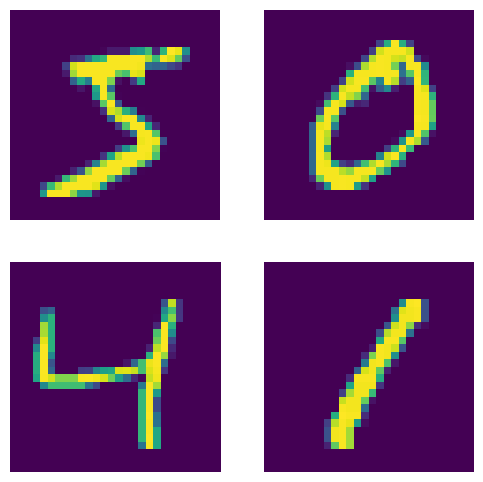

In [4]:
# 元の画像を高解像度で表示するために show_images() というヘルパー関数を利用する
from genaibook.core import show_images

show_images(mnist["train"]["image"][:4])

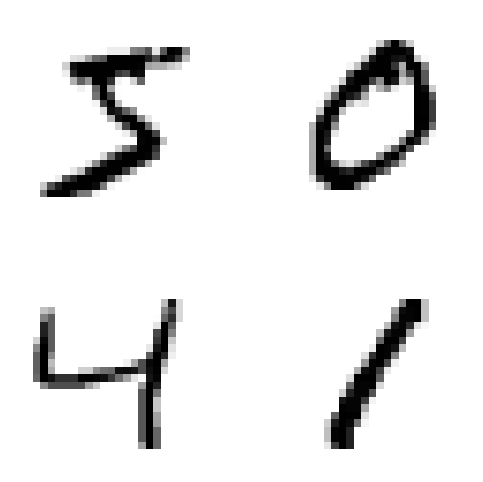

In [5]:
# 反転グレーを適用し白地に黒い数字を表示する

import matplotlib as mpl

mpl.rcParams["image.cmap"] = "gray_r"
show_images(mnist["train"]["image"][:4])

In [6]:
# 画像データを PyTorch のテンソルに変換し、訓練用データセットをシャッフルする

from torchvision import transforms

def mnist_to_tensor(samples):
  # transforms は画像の変換・拡張・操作を行う一般的なルーチンを集めたもの
  t = transforms.ToTensor()
  samples["image"] = [t(image) for image in samples["image"]]
  return samples

In [7]:
# 0 ~ 255 の範囲をとる入力ピクセルを 0 ~ 1 の範囲をとる PyTorch のテンソルに変換する
mnist = mnist.with_transform(mnist_to_tensor)
mnist["train"] = mnist["train"].shuffle(seed=1337)

In [8]:
# データセットから一枚の画像を取り出し、入力範囲を確認してみる
x = mnist["train"]["image"][0]
x.min(), x.max()

(tensor(0.), tensor(1.))

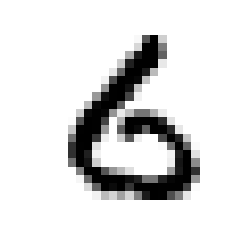

In [9]:
show_images(mnist["train"]["image"][0])

以下のコードで PyTorch の DataLoader を作成し、訓練データーの準備をする。
データセットの image 列のみ使用し、ラベルは無視する（自己教師あり学習を行うため。ラベルは後で使うけど。）

DataLoader は入力データをまとめてバッチ化する抽象化された仕組み。個々のサンプルを同じ形状の訓練バッチにまとめる役割を持つ。

In [10]:
from torch.utils.data import DataLoader

bs = 64
train_dataloader = DataLoader(mnist["train"]["image"], batch_size=bs)

3.1.2 エンコーダーのモデリング

まず、オートエンコーダーのエンコーダー部分のモデルを定義する。
画像データを扱うため画像特徴抽出に優れたものを利用する。
今回は puthae という畳み込みオートエンコーダーを使うことにする。

In [11]:
# 複数の畳み込み層を積み重ねるため、簡単なヘルパー関数 conv_block() を作成して層を作成する。

from torch import nn

def conv_block(in_channels, out_channels, kernel_size=4, stride=2, padding=1):
  return nn.Sequential(
      nn.Conv2d(
          in_channels,
          out_channels,
          kernel_size=kernel_size,
          stride=stride,
          padding=padding
      ),
      nn.BatchNorm2d(out_channels),
      nn.ReLU()
  )

In [12]:
class Encoder(nn.Module):
  def __init__(self, in_channels):
    super().__init__()
    self.conv1 = conv_block(in_channels, 128)
    self.conv2 = conv_block(128, 256)
    self.conv3 = conv_block(256, 512)
    self.conv4 = conv_block(512, 1024)
    self.linear = nn.Linear(1024, 16)

  def forward(self, x):
    x = self.conv1(x) # (batch size, 128, 14, 14)
    x = self.conv2(x) # (bs, 256, 7, 7)
    x = self.conv3(x) # (bs, 512, 3, 3)
    x = self.conv4(x) # (bs, 1024, 1, 1)
    # バッチの次元数を保持したまま平坦化する
    x = self.linear(x.flatten(start_dim=1)) # (bs, 16)
    return x

入力画像を実際にエンコーダーに渡せるか確認してみる。

In [13]:
mnist["train"]["image"][0].shape

torch.Size([1, 28, 28])

一枚の画像をバッチ化し、新たな次元を Pytorch の None インデックスとして追加する。

In [14]:
in_channels = 1

x = mnist["train"]["image"][0][None, :]
encoder = Encoder(in_channels).eval()

encoded = encoder(x)
encoded.shape

torch.Size([1, 16])

これで28*28の画像をわずか16個の数値からなるベクトルに変換できた。

十分に訓練できればエンコーダーによって計算される表現は元のピクセル余地もはるかに少ない次元のデータになる。
もちろんこの段階ではまだ訓練されていないため、この表現はまだ無意味である。⭐️どういうこっちゃ。

In [15]:
encoded

tensor([[-0.0030, -0.0209, -0.0265,  0.0060,  0.0030, -0.0171,  0.0012, -0.0118,
         -0.0008,  0.0285,  0.0245,  0.0122, -0.0275,  0.0391,  0.0275,  0.0075]],
       grad_fn=<AddmmBackward0>)

続いて、６４枚の画像からなるバッチにも対応できることを確認してみよう。

In [16]:
batch = next(iter(train_dataloader))
encoded = Encoder(in_channels=1)(batch)
batch.shape, encoded.shape

(torch.Size([64, 1, 28, 28]), torch.Size([64, 16]))

これで画像を中間表現に変換する Encoder モデルが完成した。

次はデコーダーの実装に移る。

3.1.3 デコーダー

エンコーダーから得られた潜在表現（１６次元のベクトル）を受け取り、元のサイズの画像へと変換する役割を担う。

まず線形層で16,384(1024*4*4) ピクセルのテンソルを生成し、これを4*4の解像度（[1024, 4, 4]）に整形して、最初の転移畳み込み層への入力とする。
その後チャネル数を段階的に減らしつつ解像度を上げていき、最終的に元の画像サイズにする。

In [17]:
def conv_transpose_block(
    in_channels,
    out_channels,
    kernel_size=3,
    stride=2,
    padding=1,
    output_padding=0,
    with_act=True
):
    modules = [
        nn.ConvTranspose2d(
            in_channels,
            out_channels,
            kernel_size=kernel_size,
            stride=stride,
            padding=padding,
            output_padding=output_padding
        )
    ]
    if with_act: #後々のことを考えて制御できるようにしておく
      modules.append(nn.BatchNorm2d(out_channels))
      modules.append(nn.ReLU())
    return nn.Sequential(*modules)

In [18]:
class Decoder(nn.Module):
  def __init__(self, out_channels):
    super().__init__()

    self.linear = nn.Linear(
        16, 1024 * 4 * 4
    ) # forward 内で形状が変化している点に注意
    self.t_conv1 = conv_transpose_block(1024, 512)
    self.t_conv2 = conv_transpose_block(512, 256, output_padding=1)
    self.t_conv3 = conv_transpose_block(256, out_channels, output_padding=1)

  def forward(self, x):
    bs = x.shape[0]
    x = self.linear(x) # (bs, 1024, 4, 4)
    x = x.reshape((bs, 1024, 4, 4)) # (bs, 1024, 4, 4)
    x = self.t_conv1(x) # (bs, 512, 7, 7)
    x = self.t_conv2(x) # (bs, 256, 14, 14)
    x = self.t_conv3(x) # (bs, 1, 28, 28)
    return x

In [19]:
# ここで x は mnist["train"]["image"][0] であり、その形状は torch.Size([1, 28, 28]) です。したがって、x.shape[0] は 1 となります。
# この 1 が Decoder クラスの __init__ メソッドの out_channels 引数に渡され、
# さらにそれが self.t_conv3 = conv_transpose_block(256, out_channels, output_padding=1) の out_channels に引き継がれます。
# 最終的には out_channels は１として出力するようにしている
# つまり出力が１チャネル・28px * 28px になる
decoded_batch = Decoder(x.shape[0])(encoded)
decoded_batch.shape

torch.Size([64, 1, 28, 28])

3.1.4 訓練

ここまでで、エンコーダーとデコーダーを個別に作成してきたが、今のままだと両者がランダムな重みで初期化されており、お互いに全く接続されていない状態。
これらを直列に繋げて入力データを順番に通す、AutoEncoder モデルを構築していく。

このモデルで訓練されたエンコーダーとデコーダーは個別に利用できるため、さまざまな用途に応用することができる点は興味深い。

In [20]:
# nn.Module は、すべてのニューラルネットワークモジュール（層、モデル全体など）の基底クラスとして機能します。
class AutoEncoder(nn.Module):
  def __init__(self, in_channels):
    super().__init__()
    self.encoder = Encoder(in_channels)
    self.decoder = Decoder(in_channels)

  def encode(self, x):
    return self.encoder(x)

  def decode(self, x):
    return self.decoder(x)

  def forward(self, x):
    return self.decode(self.encode(x))

In [21]:
model = AutoEncoder(1)

torchsummary ライブラリを使うと各レイヤーのパラメーター数や出力形状を示すモデルのサマリーを出力できる

In [22]:
import torchsummary

torchsummary.summary(model, input_size=(1, 28, 28), device="cpu")

# ----------------------------------------------------------------
#         Layer (type)               Output Shape         Param #
# ================================================================# --- 開始: Encoder --- (入力: [-1, 1, 28, 28], すなわち1チャンネルの28x28画像)
#             Conv2d-1          [-1, 128, 14, 14]           2,176
#        BatchNorm2d-2          [-1, 128, 14, 14]             256
#               ReLU-3          [-1, 128, 14, 14]               0 # 初期の畳み込み層。入力 [-1, 1, 28, 28] が [-1, 128, 14, 14] にダウンサンプリングされます。チャネル数は128に増加し、画像サイズは半分になります (28->14)。
#             Conv2d-4            [-1, 256, 7, 7]         524,544
#        BatchNorm2d-5            [-1, 256, 7, 7]             512
#               ReLU-6            [-1, 256, 7, 7]               0 # さらに畳み込みを行い、[-1, 256, 7, 7] へとダウンサンプリング。チャネル数は256に増加し、画像サイズはさらに半分になります (14->7)。
#             Conv2d-7            [-1, 512, 3, 3]       2,097,664
#        BatchNorm2d-8            [-1, 512, 3, 3]           1,024
#               ReLU-9            [-1, 512, 3, 3]               0 # [-1, 512, 3, 3] へとダウンサンプリング。チャネル数は512に増加し、画像サイズは3x3になります。
#            Conv2d-10           [-1, 1024, 1, 1]       8,389,632
#       BatchNorm2d-11           [-1, 1024, 1, 1]           2,048
#              ReLU-12           [-1, 1024, 1, 1]               0 # [-1, 1024, 1, 1] へとダウンサンプリング。チャネル数は1024に増加し、画像サイズは1x1の極めて小さな特徴マップになります。
#            Linear-13                   [-1, 16]          16,400 # [-1, 1024, 1, 1] の特徴マップが、x.flatten(start_dim=1) によって [-1, 1024] のベクトルに平坦化され、この全結合層を通ることで [-1, 16] の16次元の潜在表現ベクトルに圧縮されます。
#           Encoder-14                   [-1, 16]               0 # これは Encoder クラス全体の出力を示しており、形状は [-1, 16] です。ここまでがエンコーダーの役割です。
#            Linear-15                [-1, 16384]         278,528 # デコーダーの最初の層です。[-1, 16] の潜在表現がこの線形層を通ることで [-1, 16384] のより大きなベクトルに変換されます。この後、コード内で reshape((bs, 1024, 4, 4)) されるため、事実上 [-1, 1024, 4, 4] の特徴マップの準備となります。
#   ConvTranspose2d-16            [-1, 512, 7, 7]       4,719,104
#       BatchNorm2d-17            [-1, 512, 7, 7]           1,024
#              ReLU-18            [-1, 512, 7, 7]               0 # 転置畳み込み層。[-1, 1024, 4, 4] の特徴マップが [-1, 512, 7, 7] へとアップサンプリングされます。チャネル数は512に減少し、画像サイズは4x4から7x7に拡大されます。
#   ConvTranspose2d-19          [-1, 256, 14, 14]       1,179,904
#       BatchNorm2d-20          [-1, 256, 14, 14]             512
#              ReLU-21          [-1, 256, 14, 14]               0 # さらに転置畳み込みを行い、[-1, 256, 14, 14] へとアップサンプリング。チャネル数は256に減少し、画像サイズは7x7から14x14に拡大されます。
#   ConvTranspose2d-22            [-1, 1, 28, 28]           2,305
#       BatchNorm2d-23            [-1, 1, 28, 28]               2
#              ReLU-24            [-1, 1, 28, 28]               0 # 最終的な転置畳み込み層。[-1, 1, 28, 28] へとアップサンプリングされます。チャネル数は元の1に戻り、画像サイズは14x14から28x28に拡大され、元の入力画像のサイズに戻っています。
#           Decoder-25            [-1, 1, 28, 28]               0 # これは Decoder クラス全体の出力を示しており、形状は [-1, 1, 28, 28] です。これが再構築された画像です。
# ================================================================
# Total params: 17,215,635
# Trainable params: 17,215,635
# Non-trainable params: 0
# ----------------------------------------------------------------
# Input size (MB): 0.00
# Forward/backward pass size (MB): 2.86
# Params size (MB): 65.67
# Estimated Total Size (MB): 68.54
# ----------------------------------------------------------------


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 128, 14, 14]           2,176
       BatchNorm2d-2          [-1, 128, 14, 14]             256
              ReLU-3          [-1, 128, 14, 14]               0
            Conv2d-4            [-1, 256, 7, 7]         524,544
       BatchNorm2d-5            [-1, 256, 7, 7]             512
              ReLU-6            [-1, 256, 7, 7]               0
            Conv2d-7            [-1, 512, 3, 3]       2,097,664
       BatchNorm2d-8            [-1, 512, 3, 3]           1,024
              ReLU-9            [-1, 512, 3, 3]               0
           Conv2d-10           [-1, 1024, 1, 1]       8,389,632
      BatchNorm2d-11           [-1, 1024, 1, 1]           2,048
             ReLU-12           [-1, 1024, 1, 1]               0
           Linear-13                   [-1, 16]          16,400
          Encoder-14                   

以下で、シンプルな訓練ループを作成し、その中で訓練用データを繰り返し処理しながら一定の学習率でモデルを更新している。
ここでは全ての内容を細部まで理解する必要はない。以下の高レベルな処理の流れだけを抑えておけば良い。

1. DataLoader からバッチをダウンロードする
2. モデルの予測を得る
3. 元の画像に対する損失を計算する
4. オプティマイザーでモデルの重みを更新する

（tqdm は進捗表示用ライブラリ）

In [23]:
import torch
from matplotlib import pyplot as plt
from torch.nn import functional as F
from tqdm.notebook import tqdm, trange

from genaibook.core import get_device

num_epochs = 10
lr = 1e-4

device = get_device()
model = model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, eps=1e-5)

losses = [] # 描画用に損失を保存するリスト
for _ in (progress := trange(num_epochs, desc="Training")):
  for _, batch in (
      inner := tqdm(enumerate(train_dataloader), total=len(train_dataloader))
  ):
    batch = batch.to(device)

    #モデルに渡して再構成画像を取得する
    preds = model(batch)

    #予測結果と元画像を比較する
    loss = F.mse_loss(preds, batch)

    # 損失を表示し、描画用に保存する
    inner.set_postfix(loss=f"{loss.cpu().item():.3f}")
    losses.append(loss.item())

    # 損失に基づいてモデルのパラメーターを更新する
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
  progress.set_postfix(loss=f"{loss.cpu().item():.3f}", lr=f"{lr:.0e}")

Training:   0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

抽象曲線をプロットし訓練の進行状況を確認してみよう。

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


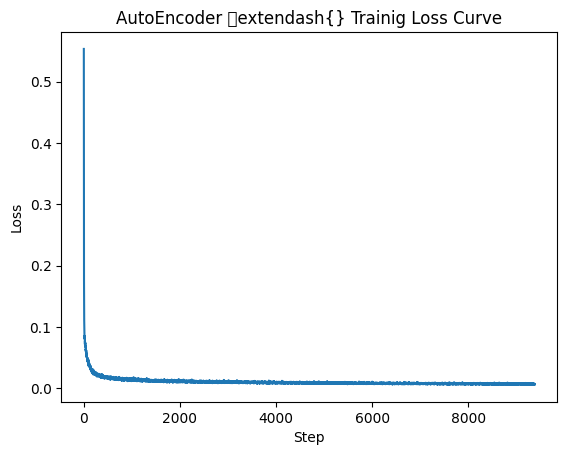

In [24]:
plt.plot(losses)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("AutoEncoder \textendash{} Trainig Loss Curve")
plt.show()

In [25]:
# テストセットから１６サンプルのバッチを作成し（１６個サンプルで作成するってこと）、訓練済みのエンコーダーとデコーダーに通し、再構成画像を表示する。
# まずは評価用のDataLoaderを作成する。

In [26]:
eval_bs = 16
eval_dataloader = DataLoader(mnist["test"]["image"], batch_size=eval_bs)

In [27]:
# model.eval() を使ってモデルを評価モードに設定する。
# これによりBatchNormの更新が無効化される。
# また inference_mode コンテキストマネージャーを使って勾配計算もオフにしておく。

model.eval()
#with は初期化と解放処理を行う Python のコンテキストマネージャーという機能を使うための構文
with torch.inference_mode():
  eval_batch = next(iter(eval_dataloader))
  predict = model(eval_batch.to(device)).cpu()

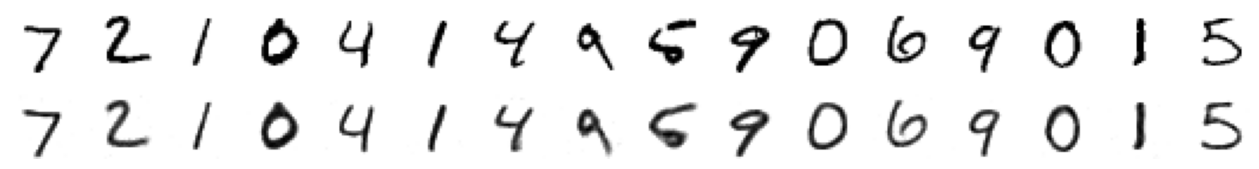

In [28]:
# 予測ができたので、元の画像とその再構成画像を表示してみよう
batch_vs_preds = torch.cat((eval_batch, predict))
show_images(batch_vs_preds, imsize=1, nrows=2)

3.1.5 潜在空間の探索

次の実験では潜在空間のベクトルを２次元だけで表現する。これまで１６次元で扱っていた潜在空間を２次元だけに縮小しても元の画像が復元できるかどうかを検証する。

コードを以下の点でリファクタリングする。
- 潜在空間をハイパーパラメーターに含める
- 畳み込み層の実装を nn.Sequential コンテナにまとめ、ネットワークの深さなどの変更を容易にする
- デコーダーの最終的な活性化関数をシグモイド関数に変更する

In [29]:
class Encoder(nn.Module):
  def __init__(self, in_channels, latent_dims):
    super().__init__()

    self.conv_layers = nn.Sequential(
        conv_block(in_channels, 128),
        conv_block(128, 256),
        conv_block(256, 512),
        conv_block(512, 1024),
    )
    self.linear = nn.Linear(1024, latent_dims)

  def forward(self, x):
    bs = x.shape[0]
    x = self.conv_layers(x) # (bs, 1024, 1, 1)
    x = self.linear(x.reshape(bs, -1))
    return x

In [30]:
class Decoder(nn.Module):
  def __init__(self, out_channels, latent_dims):
    super().__init__()

    self.linear = nn.Linear(
        latent_dims, 1024 * 4 * 4
    )
    self.t_conv_layers = nn.Sequential(
        conv_transpose_block(1024, 512),
        conv_transpose_block(512, 256, output_padding=1),
        conv_transpose_block(256, out_channels, output_padding=1, with_act=False)
    )
    self.sigmoid = nn.Sigmoid()

  def forward(self, x):
    bs = x.shape[0]
    x = self.linear(x) # (bs, 1024, 4, 4)
    x = x.reshape((bs, 1024, 4, 4)) # (bs, 1024, 4, 4)
    x = self.t_conv_layers(x) # (bs, 1, 28, 28)
    x = self.sigmoid(x)
    return x

In [31]:
# AutoEncoder は基本同じだが latent_dims を受け取るようにし、表現の次元数を２にに指定できるようにしている
class AutoEncoder(nn.Module):
  def __init__(self, in_channels, latent_dims):
    super().__init__()
    self.encoder = Encoder(in_channels, latent_dims)
    self.decoder = Decoder(in_channels, latent_dims)

  def encode(self, x):
    return self.encoder(x)

  def decode(self, x):
    return self.decoder(x)

  def forward(self, x):
    return self.decode(self.encode(x))

In [32]:
# 訓練ループも基本同じだが、再利用できるように関数化しておく
def train(model, num_epochs=10, lr=1e-4):
  optimizer = torch.optim.AdamW(model.parameters(), lr=lr, eps=1e-5)

  model = model.train() # モデルを訓練モードにする
  losses = [] # 描画用に損失を保存するリスト
  for _ in (progress := trange(num_epochs, desc="Training")):
    for _, batch in (
      inner := tqdm(
          enumerate(train_dataloader), total=len(train_dataloader)
      )
    ):
      batch = batch.to(device)

      #モデルに渡して別の画像セットを取得する
      preds = model(batch)

      #予測結果と元画像を比較する
      loss = F.mse_loss(preds, batch)

      # 損失を表示し、描画用に保存する
      inner.set_postfix(loss=f"{loss.cpu().item():.3f}")
      losses.append(loss.item())

      # 損失に基づいてモデルのパラメーターを更新する
      loss.backward()
      optimizer.step()
      optimizer.zero_grad()
    progress.set_postfix(loss=f"{loss.cpu().item():.3f}", lr=f"{lr:.0e}")
  return losses

In [33]:
# 潜在空間を２つだけ持つオートエンコーダーを作成し訓練する

ae_model = AutoEncoder(in_channels=1, latent_dims=2)
ae_model.to(device)
losses = train(ae_model)

Training:   0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

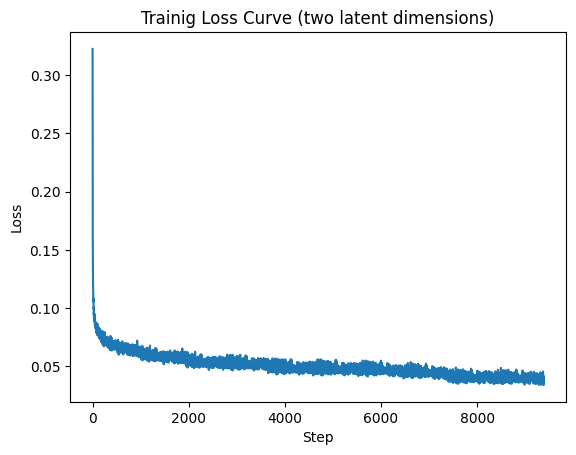

In [34]:
plt.plot(losses)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Trainig Loss Curve (two latent dimensions)")
plt.show()

In [36]:
# 訓練したモデルをロードし、再構成した結果を再度確認してみる

ae_model.eval()
with torch.inference_mode():
  eval_batch = next(iter(eval_dataloader))
  predict = ae_model(eval_batch.to(device)).cpu()

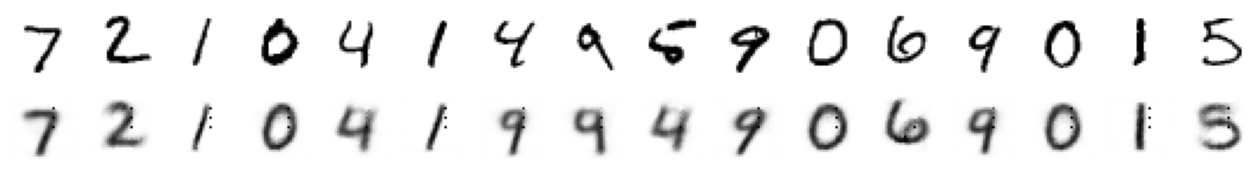

In [37]:
batch_vs_preds = torch.cat((eval_batch, predict))
show_images(batch_vs_preds, imsize=1, nrows=2)